In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

In [2]:
cpi = pd.read_excel("../data/raw/cpi.xlsx")
oni = pd.read_csv("../data/raw/oni.csv")

### <mark>CPI preprocessing</mark>

In [3]:
cpi["date"] = pd.to_datetime(
    dict(
        year=cpi["year"],
        month=cpi["month_code"],
        day=1
    )
)
cpi = cpi.sort_values("date").reset_index(drop=True)

In [4]:
# Calculating inflation for missing values using index
cpi["calculated_inflation"] = (
    cpi.groupby(
        ["state", "sector", "group", "subgroup"]
    )["index"]
    .transform(lambda x: x.pct_change(periods=12) * 100)
)

In [5]:
comparison = cpi[
    cpi["inflation"].notna() &
    cpi["calculated_inflation"].notna()
].copy()

comparison["difference"] = (
    comparison["inflation"] -
    comparison["calculated_inflation"]
)

comparison[
    ["year", "month", "index", "inflation",
     "calculated_inflation", "difference"]
].head(20)

,year,month,index,inflation,calculated_inflation,difference
24,2014,January,115.600,9.680,9.677,0.003
25,2014,February,114.800,7.890,7.895,-0.005
26,2014,March,115.700,8.640,8.638,0.002
27,2014,April,117.400,9.210,9.209,0.001
28,2014,May,118.800,8.890,8.891,-0.001
29,2014,June,120.500,7.210,7.206,0.004
30,2014,July,125.400,8.850,8.854,-0.004
31,2014,August,127.500,8.700,8.696,0.004
32,2014,September,126.400,6.220,6.218,0.002
33,2014,October,125.800,3.880,3.881,-0.001


In [6]:
# Filling the missing inflation values
cpi["inflation_calculated"] = (
    cpi.groupby(
        ["state", "sector", "group", "subgroup"]
    )["index"]
    .transform(lambda x: x.pct_change(periods=12) * 100)
)

missing_mask = cpi["inflation"].isna()

cpi.loc[missing_mask, "inflation"] = (
    cpi.loc[missing_mask, "inflation_calculated"]
)

In [7]:
cpi = cpi[["date", "inflation"]]
cpi = cpi.rename(
    columns={"inflation": "food_inflation"}
)

### <mark>ONI preprocessing</mark>

In [8]:
oni.rename(columns={'  ONI from CPC  missing value -99.9 https://psl.noaa.gov/data/timeseries/month/': "oni", "Date": "date"}, inplace=True)

In [9]:
# Change date format
oni["date"] = pd.to_datetime(
    oni["date"],
    format="%d-%m-%Y"
)

In [10]:
# Convert NOAA missing-value sentinel to NaN
oni["oni"] = oni["oni"].replace([-9999, -9999.0, -99.9], np.nan)

In [11]:
# Sort chronologically
oni = oni.sort_values("date").reset_index(drop=True)

### <mark>For merging cpi and oni data</mark>

In [12]:
START_DATE = cpi["date"].min()
END_DATE = cpi["date"].max()


oni = oni[
    (oni["date"] >= START_DATE) &
    (oni["date"] <= END_DATE)
].copy()

In [13]:
# verify no duplicate dates
print("Duplicate CPI dates:", cpi["date"].duplicated().sum())
print("Duplicate ONI dates:", oni["date"].duplicated().sum())

Duplicate CPI dates: 0
Duplicate ONI dates: 0


In [14]:
df = pd.merge(
    cpi,
    oni,
    on="date",
    how="inner"
)

df = df.sort_values("date").reset_index(drop=True)

In [15]:
df

,date,food_inflation,oni
0,2012-01-01,-0.210,-0.720
1,2012-02-01,4.450,-0.570
2,2012-03-01,7.090,-0.460
3,2012-04-01,9.320,-0.360
4,2012-05-01,9.700,-0.170
...,...,...,...
163,2025-08-01,-0.640,-0.280
164,2025-09-01,-2.330,-0.400
165,2025-10-01,-5.020,-0.510
166,2025-11-01,-3.910,-0.550


In [16]:
# Validating final dataset
print("Final shape:", df.shape)

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate dates:")
print(df["date"].duplicated().sum())

print("\nDate range:")
print(df["date"].min())
print(df["date"].max())

Final shape: (168, 3)

Missing values:
date              0
food_inflation    0
oni               0
dtype: int64

Duplicate dates:
0

Date range:
2012-01-01 00:00:00
2025-12-01 00:00:00


In [17]:
expected_months = pd.date_range(
    start=START_DATE,
    end=END_DATE,
    freq="MS"
)

print("Expected months:", len(expected_months))
print("Actual months:", len(df))

Expected months: 168
Actual months: 168


In [18]:
missing_months = expected_months.difference(df["date"])

print("Missing months:")
print(missing_months)

Missing months:
DatetimeIndex([], dtype='datetime64[us]', freq='MS')


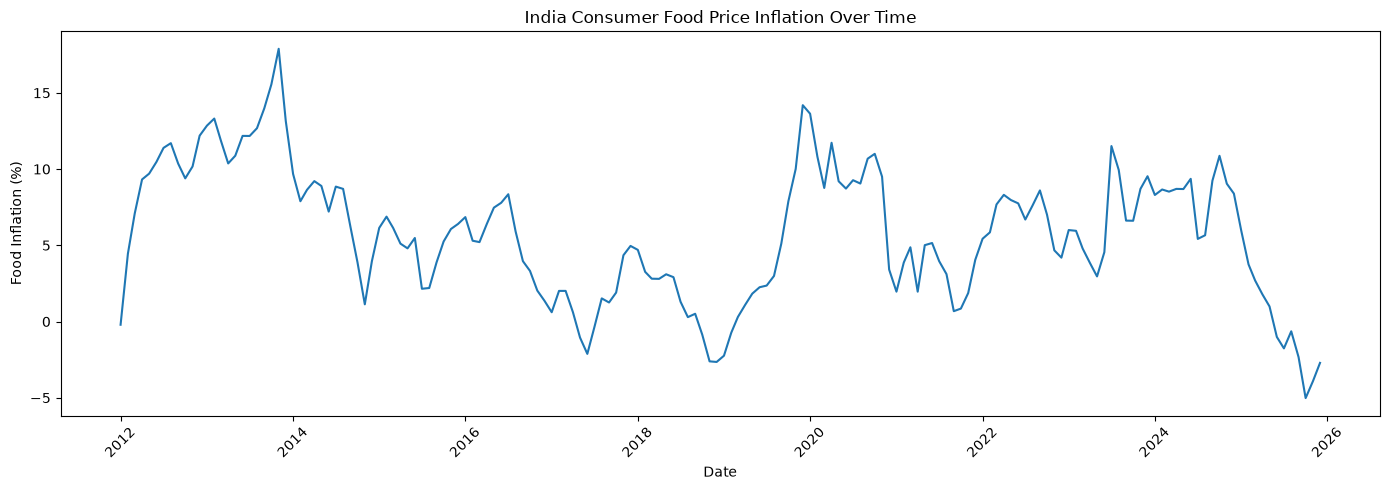

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(df["date"], df["food_inflation"])
plt.xlabel("Date")
plt.ylabel("Food Inflation (%)")
plt.title("India Consumer Food Price Inflation Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

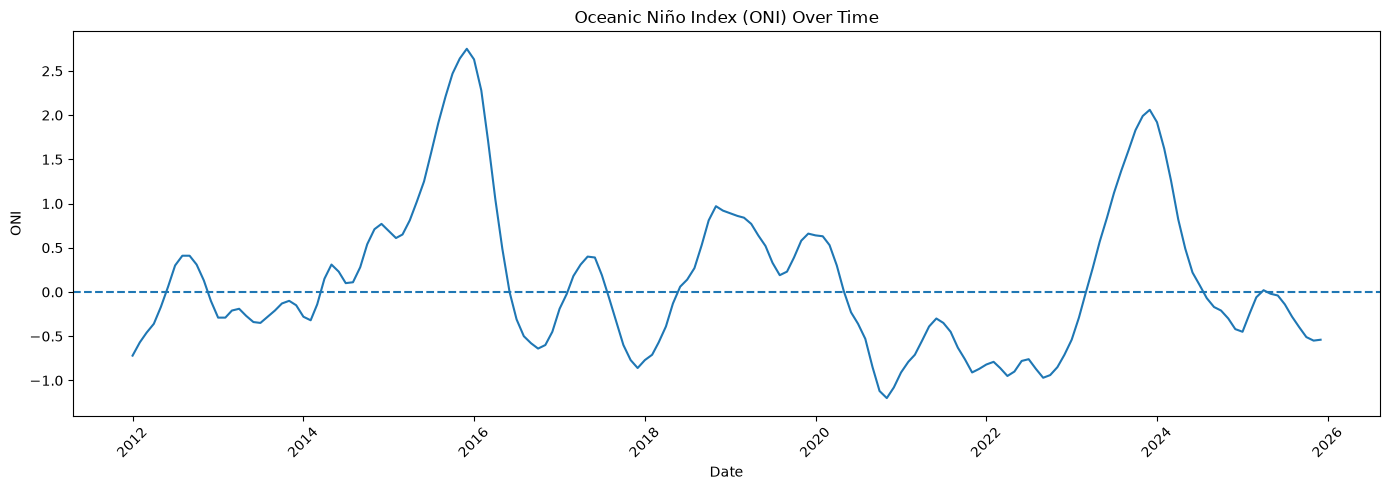

In [20]:
plt.figure(figsize=(14, 5))
plt.plot(df["date"], df["oni"])
plt.axhline(0, linestyle="--")
plt.xlabel("Date")
plt.ylabel("ONI")
plt.title("Oceanic Niño Index (ONI) Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

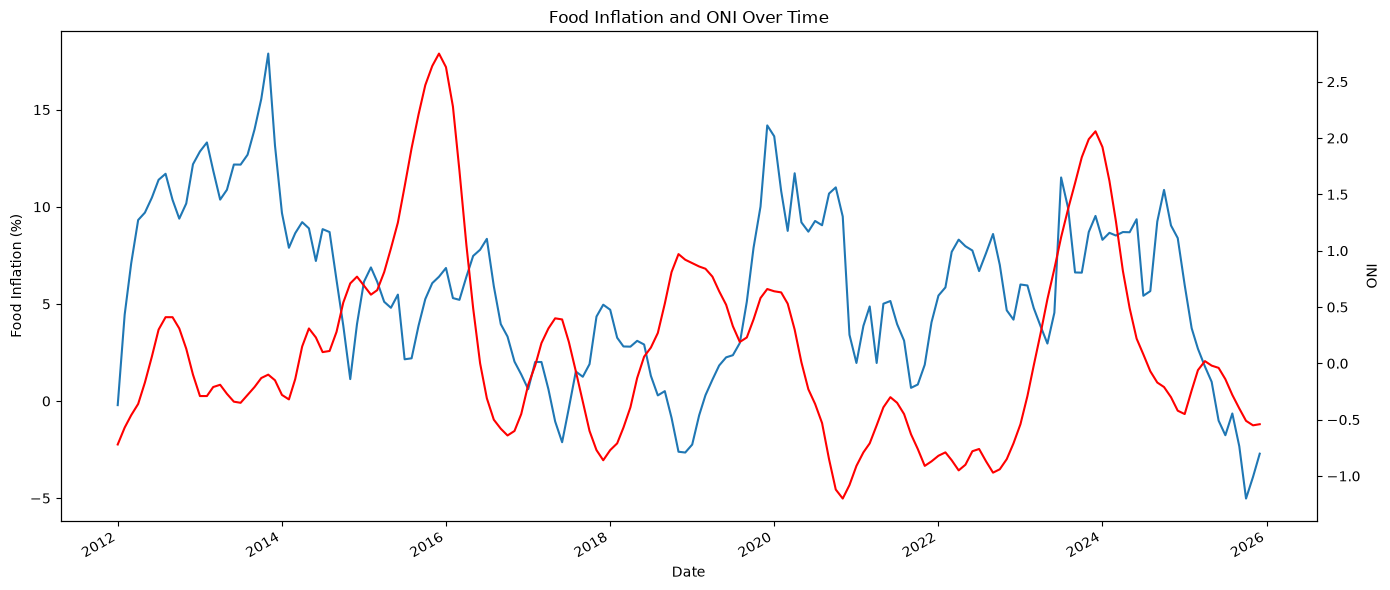

In [21]:
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(
    df["date"],
    df["food_inflation"],
    label="Food Inflation"
)
ax1.set_xlabel("Date")
ax1.set_ylabel("Food Inflation (%)")

ax2 = ax1.twinx()

ax2.plot(
    df["date"],
    df["oni"],
    label="ONI",
    color="red"
)
ax2.set_ylabel("ONI")

plt.title("Food Inflation and ONI Over Time")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

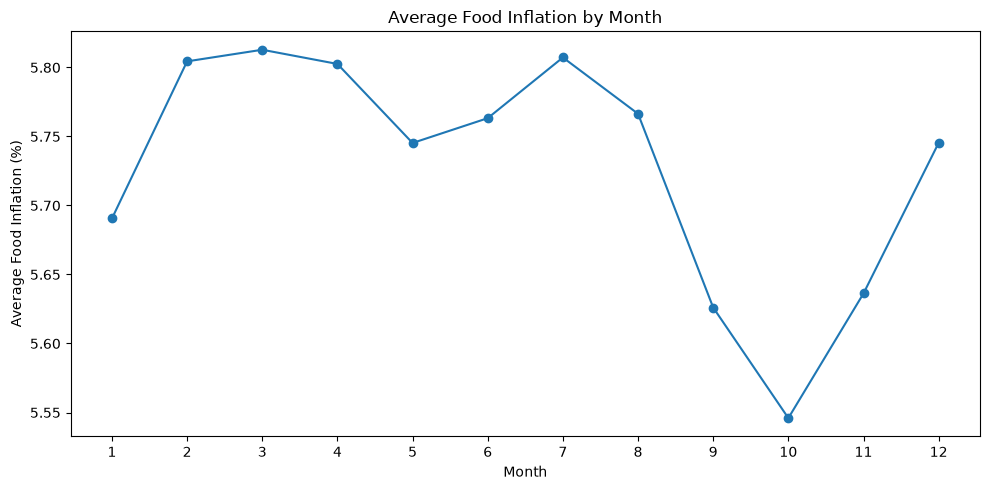

In [22]:
df["month"] = df["date"].dt.month

monthly_pattern = (
    df.groupby("month")["food_inflation"]
    .mean()
)

plt.figure(figsize=(10, 5))
plt.plot(
    monthly_pattern.index,
    monthly_pattern.values,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average Food Inflation (%)")
plt.title("Average Food Inflation by Month")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

In [23]:
df.to_csv(path_or_buf="../data/processed/cpi_oni.csv", index=False)